In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
import pathlib
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline


In [16]:

rows = []
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        sess = u.single_mouse_concat_sessions(mouse, np.arange(6), trial_mat_keys=['F_dff'], timeseries_keys=['F_dff'])
    

        pc_mask = sess.fam_place_cell_mask()+sess.nov_place_cell_mask()
        # print(pc_mask.shape)

        nov_mask= sess.trial_info['LR']==sess.novel_arm
        for day in range(5):

            day_mask = sess.trial_info['sess_num']==day

            tmat_nov = np.nanmean(sess.trial_matrices['F_dff'][nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
            maxpos_nov = np.nanargmax(tmat_nov, axis=0)
            stem_cell_nov = maxpos_nov<10
            
            tmat_fam = np.nanmean(sess.trial_matrices['F_dff'][~nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
            # print(tmat_fam.shape)
            maxpos_fam = np.nanargmax(tmat_fam, axis=0)
            stem_cell_fam = maxpos_fam<10
            
            start_cell_mask =  stem_cell_nov * stem_cell_fam * (np.abs(maxpos_fam-maxpos_nov)<=3)
            # r_cell_mask = (np.abs(rel_pos_fam-rel_pos_nov)<=2)
            o_cell_mask = ~start_cell_mask
            
            for next_day in range(day+1,6):
                next_day_mask = sess.trial_info['sess_num']==next_day
                for ttype in ('nov', 'fam'):
                    if ttype == 'nov':
                        n_mask = nov_mask
                        day_mat = tmat_nov
                        day_pos = maxpos_nov
                        
                    else:
                        n_mask = ~nov_mask
                        day_mat = tmat_fam
                        day_pos = maxpos_fam
                       
                    
                    next_day_tmat = np.nanmean(sess.trial_matrices['F_dff'][n_mask*next_day_mask,:,:][:,:,pc_mask],axis=0)
                    next_day_pos = np.nanargmax(next_day_tmat,axis=0)
                    
                    
                    next_day_corr = np.zeros([next_day_tmat.shape[1],])
                    for cell in range(next_day_tmat.shape[1]):
                        r, _ = sp.stats.pearsonr(day_mat[:,cell], next_day_tmat[:,cell])
                        next_day_corr[cell]=r

                    for (ndc, d_p, nd_p) in zip(next_day_corr[start_cell_mask], 
                                            day_pos[start_cell_mask], 
                                            next_day_pos[start_cell_mask]):
                        rows.append({'cond': cond,
                                    'mouse': mouse, 
                                    'day': day,
                                    'next_day': next_day,
                                    'ttype': ttype,
                                    'stem_cell': True,
                                    'next_day_corr': ndc,
                                    'day_pos': d_p,
                                    'next_day_pos': nd_p})
                    
                        
                    for (ndc, d_p, nd_p) in zip(next_day_corr[o_cell_mask],
                                            day_pos[o_cell_mask], 
                                            next_day_pos[o_cell_mask]):
                        rows.append({'cond': cond,
                                    'mouse': mouse, 
                                    'day': day,
                                    'next_day': next_day,
                                    'ttype': ttype,
                                    'stem_cell': False,
                                    'next_day_corr': ndc,
                                    'day_pos': d_p,
                                    'next_day_pos': nd_p})

df = pd.DataFrame(rows)
df['pos_diff']= np.abs(df['next_day_pos']-df['day_pos'])


4467331.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467331.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467333.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


05_12_2020 YMaze_LNovel
mCherry6
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry7
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry8
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
mCherry9
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


28_09_2020 YMaze_LNovel


...

01_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


02_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


03_10_2020 YMaze_LNovel
4467975.4
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
4467975.5
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
Cre7
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
22_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
Cre9
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


In [30]:
# correlation matrices across days

corr_mat = {}
for cond, mice  in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):

    corr_mat[cond] = {'fam': {'stem_cell': None,
                              'other_cell': None},
                      'nov': {'stem_cell': None,
                              'other_cell': None}
                     }
    print(cond)

    for ttype in ('fam', 'nov'):
        for stem_cell in (False, True):
            mat = np.nan*np.zeros([6,6, len(mice)])
            for day in range(5):
                for next_day in range(day+1, 6):
                
                    mask = (df['cond']==cond) * (df['day']==day) * (df['next_day']==next_day) * (df['ttype']==ttype) * (df['stem_cell']==stem_cell)

                    tmp_df = df.loc[mask].groupby(['mouse', 'stem_cell'])['next_day_corr'].mean().reset_index()
                    # print(tmp_df['mouse'].unique())
                    # print(cond, ttype, reward_cell, day, next_day)
                    for i, mouse in enumerate(mice):
                        mouse_mask = tmp_df['mouse']==mouse
                        if mouse_mask.sum()>0:
                            mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values

            if stem_cell:
                corr_mat[cond][ttype]['stem_cell'] = mat
            else:
                corr_mat[cond][ttype]['other_cell'] = mat




ctrl


/tmp/ipykernel_337463/140581479.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp/ipykernel_337463/140581479.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp/ipykernel_337463/140581479.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp/ip

ko


/tmp/ipykernel_337463/140581479.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp/ipykernel_337463/140581479.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp/ipykernel_337463/140581479.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[day, next_day,i] = tmp_df.loc[mouse_mask,'next_day_corr'].values
/tmp/ip

/tmp/ipykernel_337463/243278483.py:6: RuntimeWarning: Mean of empty slice
  h = ax[i,0].imshow(np.nanmean(tr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
/tmp/ipykernel_337463/243278483.py:11: RuntimeWarning: Mean of empty slice
  h=ax[i,1].imshow(np.nanmean(rr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
/tmp/ipykernel_337463/243278483.py:16: RuntimeWarning: Mean of empty slice
  h=ax[i,2].imshow(np.nanmean(diff_mat, axis=-1), cmap='PuOr', vmin=-.1, vmax=.1)


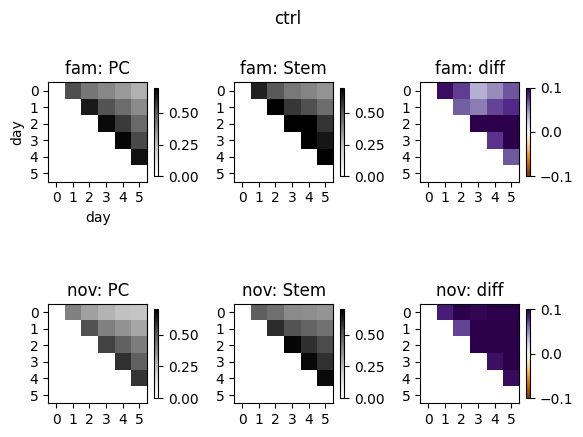

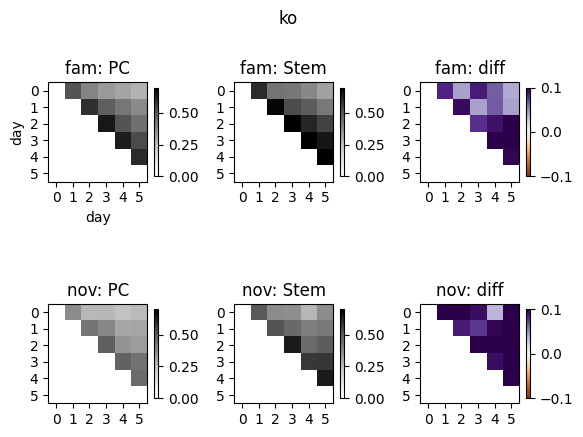

In [31]:
for cond in ('ctrl', 'ko'):
    fig, ax = plt.subplots(2,3)
    fig.subplots_adjust(wspace=.5, hspace=.5)
    for i, ttype in enumerate(('fam', 'nov')):
        tr_mat = corr_mat[cond][ttype]['other_cell']
        h = ax[i,0].imshow(np.nanmean(tr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
        ax[i,0].set_title(f'{ttype}: PC')
        fig.colorbar(h, shrink=.6)

        rr_mat = corr_mat[cond][ttype]['stem_cell']
        h=ax[i,1].imshow(np.nanmean(rr_mat,axis=-1), cmap='Greys', vmin=0, vmax=.7)
        ax[i,1].set_title(f'{ttype}: Stem')
        fig.colorbar(h, shrink=.6)

        diff_mat = rr_mat-tr_mat
        h=ax[i,2].imshow(np.nanmean(diff_mat, axis=-1), cmap='PuOr', vmin=-.1, vmax=.1)
        ax[i,2].set_title(f'{ttype}: diff')
        fig.colorbar(h, shrink=.6)

    fig.suptitle(cond)

    for a in ax.flatten():
        a.set_xticks(np.arange(6))
        a.set_yticks(np.arange(6))
    ax[0,0].set_xlabel('day')
    ax[0,0].set_ylabel('day')

/tmp/ipykernel_337463/3588331211.py:5: RuntimeWarning: Mean of empty slice
  h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=.7)
/tmp/ipykernel_337463/3588331211.py:10: RuntimeWarning: Mean of empty slice
  h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=.7)


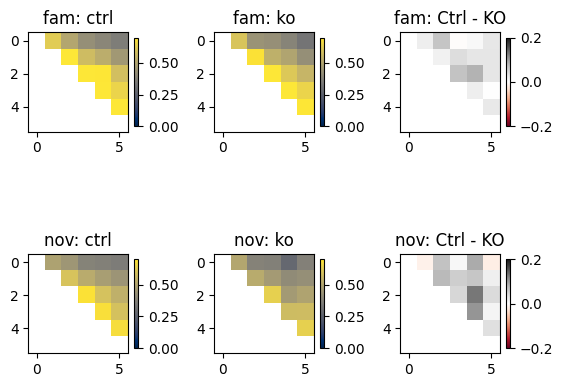

In [32]:
fig, ax = plt.subplots(2,3)
fig.subplots_adjust(wspace=.5, hspace=.5)
for r, ttype in enumerate(('fam','nov')):
    ctrl_rr_mat = corr_mat['ctrl'][ttype]['stem_cell']
    h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=.7)
    ax[r,0].set_title(f'{ttype}: ctrl')
    fig.colorbar(h, shrink=.6)

    ko_rr_mat = corr_mat['ko'][ttype]['stem_cell']
    h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=.7)
    ax[r,1].set_title(f'{ttype}: ko')
    fig.colorbar(h, shrink=.6)

    diff = ctrl_rr_mat.mean(axis=-1) - ko_rr_mat.mean(axis=-1)
    h = ax[r,2].imshow(diff, cmap='RdGy', vmin=-.2, vmax=.2)
    fig.colorbar(h, shrink=.6)
    ax[r,2].set_title(f'{ttype}: Ctrl - KO')
# fig.savefig(figdir / 'next_day_corr_heatmaps.svg')

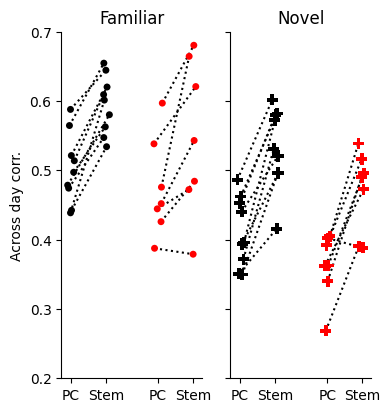

In [33]:

fig, ax = plt.subplots(1,2,figsize=[4,4.5], sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'ttype', 'stem_cell'])['next_day_corr'].mean().reset_index()
tmp_df['tmp_x'] = 1.*(tmp_df['cond']=='ko')
sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='next_day_corr', hue='stem_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[0], legend=False, dodge=True)
d=0
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='next_day_corr', hue='stem_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=0
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='next_day_corr', hue='stem_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[0], legend=False, dodge=True)
d=2
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='next_day_corr', hue='stem_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=2
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax[0].set_title('Familiar')
ax[1].set_title('Novel')
for a in ax.flatten():
    a.set_xticks([-.2, .2, .8,1.2], labels=['PC', 'Stem', 'PC', 'Stem'])

    a.set_ylim([.2,.7])
    
    a.set_ylabel('Across day corr.')
    a.set_xlabel('')

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

# fig.savefig(figdir / f'next_day_corr_summary.svg')

In [34]:
stem_ctrl =  tmp_df.loc[(tmp_df['stem_cell']==True) * (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')]
tr_ctrl = tmp_df.loc[(tmp_df['stem_cell']==False) * (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')]
diff_ctrl = tr_ctrl['next_day_corr'].values - stem_ctrl['next_day_corr'].values

stem_ko =  tmp_df.loc[(tmp_df['stem_cell']==True) * (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')]
tr_ko = tmp_df.loc[(tmp_df['stem_cell']==False) * (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')]
diff_ko = tr_ko['next_day_corr'].values - stem_ko['next_day_corr'].values

In [35]:
t, p = sp.stats.mannwhitneyu(stem_ctrl['next_day_corr'].values, stem_ko['next_day_corr'].values)
print(t, p)

51.0 0.04178321678321679


In [36]:
t, p = sp.stats.mannwhitneyu(tr_ctrl['next_day_corr'].values, tr_ko['next_day_corr'].values)
print(t, p)

46.0 0.14160839160839161


In [37]:

df['abs_pos_shift'] = np.abs(df['day_pos']-df['next_day_pos'])
df['pos_shift'] = df['next_day_pos']-df['day_pos']

In [38]:
shift_mat = {}
for cond, mice  in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):

    shift_mat[cond] = {'fam': {'stem_cell': None,
                              'tr_cell': None},
                      'nov': {'stem_cell': None,
                              'tr_cell': None}
                     }

    for ttype in ('fam', 'nov'):
        for stem_cell in (False, True):
            mat = np.nan*np.zeros([6,6, len(mice)])
            for day in range(5):
                for next_day in range(day+1, 6):
                
                    mask = (df['cond']==cond) * (df['day']==day) * (df['next_day']==next_day) * (df['ttype']==ttype) * (df['stem_cell']==stem_cell)

                    tmp_df = df.loc[mask].groupby(['mouse', 'stem_cell'])['abs_pos_shift'].mean().reset_index()
                    for i, mouse in enumerate(mice):
                        mouse_mask = tmp_df['mouse']==mouse
                        if mouse_mask.sum()>0:
                            mat[day, next_day,i] = tmp_df.loc[mouse_mask,'abs_pos_shift'].values[0]
                    

            if stem_cell:
                shift_mat[cond][ttype]['stem_cell'] = mat
            else:
                shift_mat[cond][ttype]['tr_cell'] = mat


/tmp/ipykernel_337463/2256637768.py:6: RuntimeWarning: Mean of empty slice
  h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
/tmp/ipykernel_337463/2256637768.py:11: RuntimeWarning: Mean of empty slice
  h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)


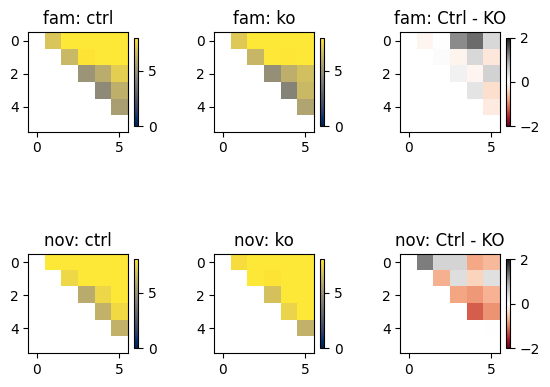

In [39]:
fig, ax = plt.subplots(2,3)
fig.subplots_adjust(wspace=.5, hspace=.5)

for r, ttype in enumerate(('fam','nov')):
    ctrl_rr_mat = shift_mat['ctrl'][ttype]['stem_cell']
    h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
    ax[r,0].set_title(f'{ttype}: ctrl')
    fig.colorbar(h, shrink=.6)

    ko_rr_mat = shift_mat['ko'][ttype]['stem_cell']
    h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
    ax[r,1].set_title(f'{ttype}: ko')
    fig.colorbar(h, shrink=.6)

    diff = ctrl_rr_mat.mean(axis=-1) - ko_rr_mat.mean(axis=-1)
    h = ax[r,2].imshow(diff, cmap='RdGy', vmin=-2, vmax=2)
    fig.colorbar(h, shrink=.6)
    ax[r,2].set_title(f'{ttype}: Ctrl - KO')
# fig.savefig(figdir / 'rr_shift_heatmaps.svg')

/tmp/ipykernel_337463/2999635674.py:6: RuntimeWarning: Mean of empty slice
  h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
/tmp/ipykernel_337463/2999635674.py:11: RuntimeWarning: Mean of empty slice
  h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)


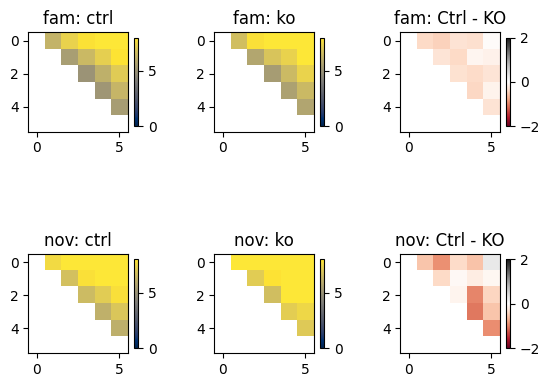

In [40]:
fig, ax = plt.subplots(2,3)
fig.subplots_adjust(wspace=.5, hspace=.5)

for r, ttype in enumerate(('fam','nov')):
    ctrl_rr_mat = shift_mat['ctrl'][ttype]['tr_cell']
    h=ax[r,0].imshow(np.nanmean(ctrl_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
    ax[r,0].set_title(f'{ttype}: ctrl')
    fig.colorbar(h, shrink=.6)

    ko_rr_mat = shift_mat['ko'][ttype]['tr_cell']
    h=ax[r,1].imshow(np.nanmean(ko_rr_mat,axis=-1), cmap='cividis', vmin=0, vmax=8)
    ax[r,1].set_title(f'{ttype}: ko')
    fig.colorbar(h, shrink=.6)

    diff = ctrl_rr_mat.mean(axis=-1) - ko_rr_mat.mean(axis=-1)
    h = ax[r,2].imshow(diff, cmap='RdGy', vmin=-2, vmax=2)
    fig.colorbar(h, shrink=.6)
    ax[r,2].set_title(f'{ttype}: Ctrl - KO')
# fig.savefig(figdir / 'tr_shift_heatmaps.svg')

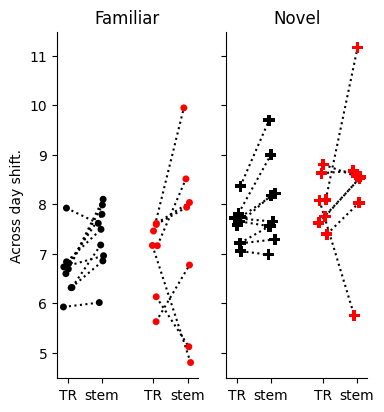

In [41]:
fig, ax = plt.subplots(1,2,figsize=[4,4.5], sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'ttype', 'stem_cell'])['abs_pos_shift'].mean().reset_index()
tmp_df['tmp_x'] = 1.*(tmp_df['cond']=='ko')
sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='abs_pos_shift', hue='stem_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[0], legend=False, dodge=True)
d=0
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ctrl') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='abs_pos_shift', hue='stem_cell',hue_order=[False,True],
              palette=['black','black'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=0
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='fam')],
              x='tmp_x', y='abs_pos_shift', hue='stem_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[0], legend=False, dodge=True)
d=2
for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
    ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

sns.stripplot(data = tmp_df.loc[ (tmp_df['cond']=='ko') * (tmp_df['ttype']=='nov')],
              x='tmp_x', y='abs_pos_shift', hue='stem_cell',hue_order=[False,True],
              palette=['red','red'],ax=ax[1], legend=False, dodge=True, marker='P', s=8)
d=2
for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
    ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax[0].set_title('Familiar')
ax[1].set_title('Novel')
for a in ax.flatten():
    a.set_xticks([-.2, .2, .8,1.2], labels=['TR', 'stem', 'TR', 'stem'])

    # a.set_ylim([0,10])
    
    a.set_ylabel('Across day shift.')
    a.set_xlabel('')

    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
# fig.savefig(figdir / 'shift_summary.svg')

SyntaxError: incomplete input (130664453.py, line 1)